In [8]:
1+1

2

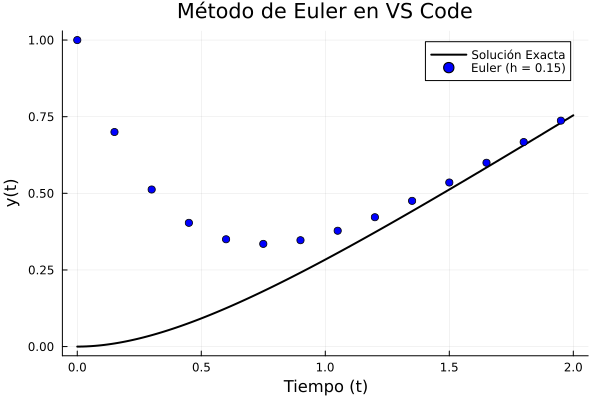

In [9]:
using Plots

# 1. Definición de la EDO y solución exacta
f(t, y) = -2 * y + t
y_exacta(t) = 0.25 * exp(-2*t) + 0.5*t - 0.25

# 2. Algoritmo de Euler Explícito
function euler(f, t0, tf, y0, h)
    t = collect(t0:h:tf)
    N = length(t)
    y = zeros(N)
    y[1] = y0
    for i in 1:(N - 1)
        y[i+1] = y[i] + h * f(t[i], y[i])
    end
    return t, y
end

# 3. Cálculo y Graficación
t_num, y_num = euler(f, 0.0, 2.0, 1.0, 0.15)
t_fino = 0.0:0.01:2.0

plot(t_fino, y_exacta.(t_fino), label="Solución Exacta", lw=2, color=:black)
scatter!(t_num, y_num, label="Euler (h = 0.15)", marker=:circle, color=:blue)
title!("Método de Euler en VS Code")
xlabel!("Tiempo (t)")
ylabel!("y(t)")

In [10]:
using Plots

# 1. Definición de la EDO y su solución exacta
f(t, y) = -2 * y + t
y_exacta(t) = 0.25 * exp(-2*t) + 0.5*t - 0.25

# 2. Algoritmo de Euler Explícito
function euler(f, t0, tf, y0, h)
    t = collect(t0:h:tf)
    N = length(t)
    y = zeros(N)
    y[1] = y0
    for i in 1:(N - 1)
        y[i+1] = y[i] + h * f(t[i], y[i])
    end
    return t, y
end

# 3. Parámetros
t0, tf, y0, h = 0.0, 2.0, 1.0, 0.15
t_num, y_num = euler(f, t0, tf, y0, h)
t_fino = 0.0:0.01:tf

# 4. Generar Animación Paso a Paso
anim = @animate for i in 1:length(t_num)
    # Dibujar curva exacta de fondo
    plot(t_fino, y_exacta.(t_fino), label="Solución Exacta", lw=2, color=:black)
    
    # POLIGONAL DE EULER: Lógrala combinando línea continua (lw=2) y puntos (marker=:circle)
    plot!(t_num[1:i], y_num[1:i], 
          label="Poligonal Euler (h = $h)", 
          lw=2, color=:purple, marker=:circle, markersize=5)
    
    # Destacar en rojo el paso recién calculado
    scatter!([t_num[i]], [y_num[i]], color=:red, markersize=7, label=false)
    
    # Configuración de ejes y títulos
    xlims!(t0 - 0.05, tf + 0.05)
    ylims!(-0.05, 1.05)
    title!("Construcción de la Poligonal de Euler (Paso $i de $(length(t_num)))")
    xlabel!("Tiempo (t)")
    ylabel!("y(t)")
end

# 5. Renderizar la animación en Jupyter
mp4(anim, "euler.mp4", fps = 3)


[ Info: Saved animation to c:\Users\División Matemáticas\AppData\Local\Programs\Microsoft VS Code\euler.mp4


Plots.AnimatedGif("c:\\Users\\División Matemáticas\\AppData\\Local\\Programs\\Microsoft VS Code\\euler.mp4")

In [11]:
using Plots

# 1. Definición de la EDO y solución exacta
f(t, y) = -2 * y + t
y_exacta(t) = 0.25 * exp(-2*t) + 0.5*t - 0.25

# 2. Algoritmo de Euler
function euler(f, t0, tf, y0, h)
    t = collect(t0:h:tf)
    N = length(t)
    y = zeros(N)
    y[1] = y0
    for i in 1:(N - 1)
        y[i+1] = y[i] + h * f(t[i], y[i])
    end
    return t, y
end

# 3. Parámetros y cálculo para dos pasos distintos
t0, tf, y0 = 0.0, 2.0, 1.0

# Paso grande (h1) y Paso fino (h2)
h1 = 0.3
h2 = 0.05

t_num1, y_num1 = euler(f, t0, tf, y0, h1)
t_num2, y_num2 = euler(f, t0, tf, y0, h2)

t_fino = 0.0:0.01:tf

# 4. Generar Animación Comparativa
# Animamos usando los índices del paso más fino (h2)
anim = @animate for i in 1:length(t_num2)
    t_actual = t_num2[i]
    
    # Graficar la curva exacta continua
    plot(t_fino, y_exacta.(t_fino), label="Solución Exacta", lw=2.5, color=:black)
    
    # --- Poligonal con h grande (h1 = 0.3) ---
    # Buscamos qué puntos del paso grande han ocurrido hasta el tiempo actual
    idx1 = findall(t -> t <= t_actual + 1e-5, t_num1)
    plot!(t_num1[idx1], y_num1[idx1], 
          label="Euler Grueso (h = $h1)", 
          lw=2, color=:red, marker=:circle, markersize=5)
    
    # --- Poligonal con h fino (h2 = 0.05) ---
    plot!(t_num2[1:i], y_num2[1:i], 
          label="Euler Fino (h = $h2)", 
          lw=2, color=:blue, marker=:circle, markersize=4)
    
    # --- Cálculo de Errores en tiempo real ---
    y_real = y_exacta(t_actual)
    y_e2 = y_num2[i]
    err2 = abs(y_real - y_e2)
    
    # Obtener el valor más reciente de h1
    y_e1 = y_num1[idx1[end]]
    err1 = abs(y_exacta(t_num1[idx1[end]]) - y_e1)
    
    # Mostrar el marcador actual del paso fino
    scatter!([t_actual], [y_e2], color=:blue, markersize=6, label=false)
    
    # Cuestión gráfica: Anotación de texto con el error en la esquina
    texto_error = "Tiempo t = $(round(t_actual, digits=2))\n" *
                  "Error (h=$h1): $(round(err1, digits=4))\n" *
                  "Error (h=$h2): $(round(err2, digits=4))"
    
    annotate!(1.35, 0.25, text(texto_error, :left, 9, :black, "Courier"))
    
    # Configuración del gráfico
    xlims!(t0 - 0.05, tf + 0.05)
    ylims!(-0.05, 1.05)
    title!("Efecto del tamaño de paso (h) y Error Numérico")
    xlabel!("Tiempo (t)")
    ylabel!("y(t)")
end

# 5. Generar reproductor de video interactivo
mp4(anim, "euler_comparativo.mp4", fps = 5)

[ Info: Saved animation to c:\Users\División Matemáticas\AppData\Local\Programs\Microsoft VS Code\euler_comparativo.mp4


Plots.AnimatedGif("c:\\Users\\División Matemáticas\\AppData\\Local\\Programs\\Microsoft VS Code\\euler_comparativo.mp4")